# 1. Business Understanding
---
El objetivo del proyecto es clasificar automáticamente los tipos de ataques y sus categorías utilizando descripciones técnicas y vulnerabilidades.

**Requisitos Funcionales:** Clasificación, identificación de categorías, análisis de vulnerabilidades, visualización, filtrado y predicción.

# 2. Data Understanding (EDA)
---
En esta etapa exploramos la estructura del dataset y las relaciones entre variables.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
%matplotlib inline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split


from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, recall_score

# Balanceo
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Deep Learning

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder


# SHAP
import shap

import joblib


Importamos dataset

In [16]:
df = pd.read_csv('Attack_Dataset.csv', sep=",")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack Type           14133 non-null  str  
 4   Scenario Description  14133 non-null  str  
 5   Tools Used            14119 non-null  str  
 6   Attack Steps          14133 non-null  str  
 7   Target Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
 15  Unnamed: 15           46 non-null     str  
dtypes: int64(1), st

El dataset contiene 14.133 registros y 16 variables

## 2.1 Análisis Estadístico y Visual
Se analizan las categorías, objetivos y la relación entre variables.

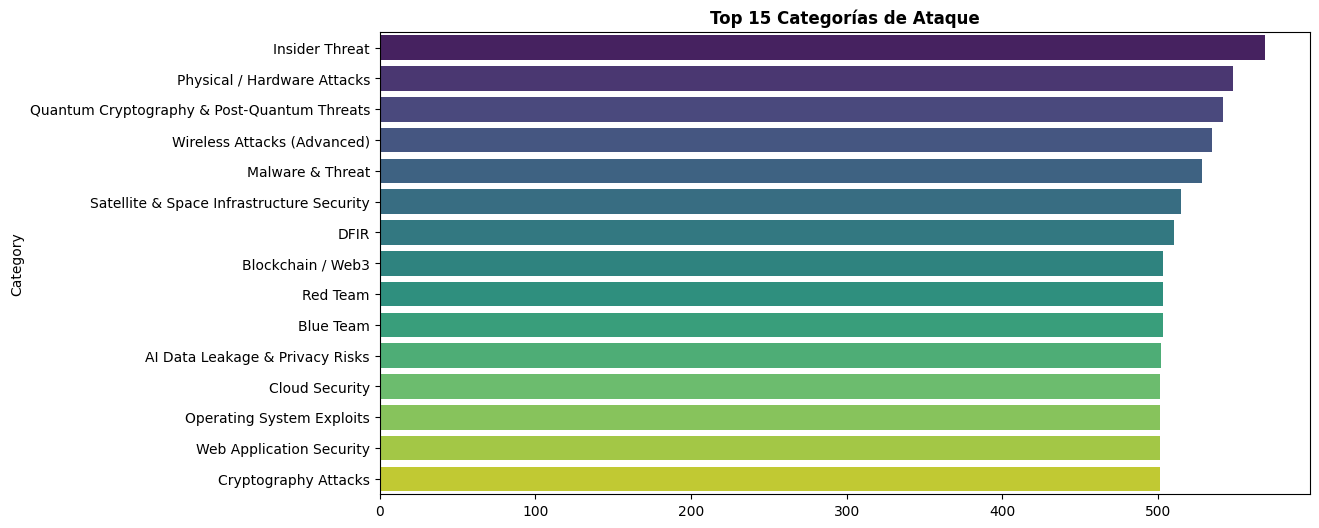

In [17]:
# Figura: Top Categorías
plt.figure(figsize=(12, 6))
top_categories = df['Category'].value_counts().head(15)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette="viridis", legend=False)
plt.title('Top 15 Categorías de Ataque', fontweight='bold')
plt.show()

In [19]:
# Matriz de Co-ocurrencia
top_cat_heatmap = df['Category'].value_counts().head(10).index
top_att_heatmap = df['Attack Type'].value_counts().head(10).index
filtered_heat = df[(df['Category'].isin(top_cat_heatmap)) & (df['Attack Type'].isin(top_att_heatmap))]

pd.crosstab(filtered_heat['Category'], filtered_heat['Attack Type'], margins=True).style.background_gradient(cmap="Blues")

Attack Type,Data Exfiltration,Hardware Interface Exploitation,Misuse of Legitimate Tools,Privilege Escalation,Removable Media Attack,Wireless Attacks (Advanced),All
Category,,,,,,,
Blue Team,8,0,0,3,0,0,11
DFIR,0,0,0,1,0,0,1
Insider Threat,37,0,55,45,0,0,137
Physical / Hardware Attacks,0,161,0,0,55,0,216
Quantum Cryptography & Post-Quantum Threats,0,0,0,0,0,95,95
Red Team,0,0,0,2,0,0,2
All,45,161,55,51,55,95,462


Se observa una alta correlación entre 'Category' y 'Attack Type', lo que valida la viabilidad de un modelo supervisado.

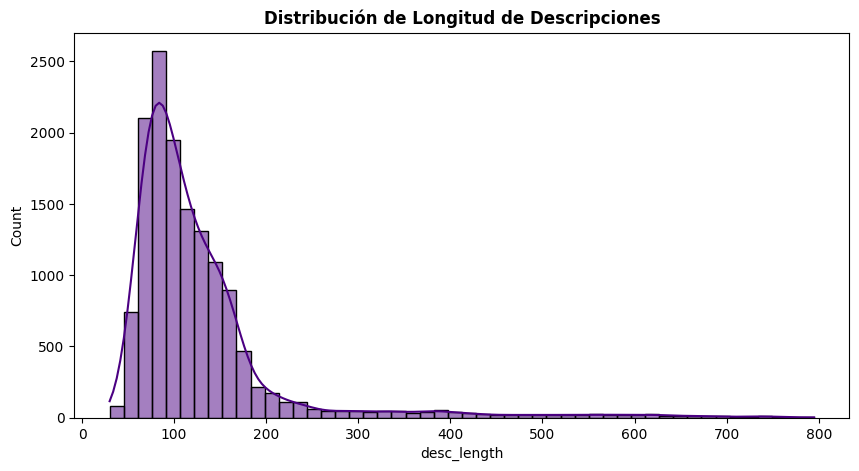

In [20]:
df['desc_length'] = df['Scenario Description'].fillna('').apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(df['desc_length'], bins=50, kde=True, color='indigo')
plt.title('Distribución de Longitud de Descripciones', fontweight='bold')
plt.show()

# 3. Data Preparation
---
Se identificaron valores nulos en múltiples variables como Vulnerability (18) y MITRE Technique (24).

La columna Unnamed: 15 corresponde a una variable basura, por lo que será eliminada.
En 'Attack Steps ' se observa un espacio que será eliminado.
Imputación de valores faltantes

In [21]:
df.drop(columns=['Unnamed: 15'], inplace=True, errors='ignore')
df.columns = df.columns.str.strip()

cols = ['Title', 'Scenario Description', 'Vulnerability', 'MITRE Technique']
df[cols] = df[cols].fillna('')


Transformamos el texto a minúscula evitando la duplicidad de palabras.

In [25]:
# Creación de la variable combinada

df['text'] = (df['Title'] + " " + df['Scenario Description'] +
              " " + df['Vulnerability'] + " " + df['MITRE Technique']).str.lower()

Existe un **desbalanceo de clases:** algunos tipos de ataques cuentan con una sola ocurrencia, por lo que no podrán utilizarse tras la división del dataset. Por lo tanto, se considerarán clases válidas únicamente aquellas con al menos dos instancias.

In [22]:
# Manejo de Desbalanceo
counts = df['Category'].value_counts()
valid_classes = counts[counts >= 2].index
df = df[df['Category'].isin(valid_classes)]

In [23]:
print(f"Registros tras limpieza: {df.shape[0]}")

Registros tras limpieza: 14132


# 4. Modelling
---

Se realiza la división de datos: Train 80% / Test 20%

In [26]:
# Definición de X e y

X = df['text']
y = df['Category']


Determinamos la variable Target [x]: Category<br>
Determinamos la variable Features [y]: Title, Scenario Description, Vulnerability y MITRE Technique

# 5. Evaluation
---
Verificación de métricas y explicabilidad.

In [27]:
# VECTORIZE (TF-IDF)

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


# BALANCEO DE DATOS

# Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)


# MODELOS ML

models = {
    "LinearSVC": LinearSVC(class_weight='balanced'),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "LogisticRegression": LogisticRegression(max_iter=1000)
}


results = {}

for name, model in models.items():
    model.fit(X_ros, y_ros)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    results[name] = (acc, f1, recall)

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("Recall:", recall)
    print(classification_report(y_test, y_pred, zero_division=0))






=== LinearSVC ===
Accuracy: 0.6614785992217899
F1-score: 0.6620980118997958
Recall: 0.6614785992217899
                                                                                                             precision    recall  f1-score   support

                                                                                   AI Agents & LLM Exploits       0.63      0.53      0.57        99
                                                                            AI Data Leakage & Privacy Risks       0.68      0.78      0.73       100
                                                                                             AI/ML Security       0.77      0.73      0.75        99
                                                                                           Automotive / CPS       0.00      0.00      0.00         2
                                                      Automotive / CPS → Firmware Over-The-Air (FOTA) Abuse       0.00      0.00      0.00         1
 

/Users/ximenacortes/Downloads/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
df_results = pd.DataFrame(results, index=['Accuracy', 'F1', 'Recall']).T

print("RESUMEN MODELOS")
print(df_results)

RESUMEN MODELOS
                    Accuracy        F1    Recall
LinearSVC           0.661479  0.662098  0.661479
RandomForest        0.657588  0.651560  0.657588
LogisticRegression  0.651220  0.656732  0.651220


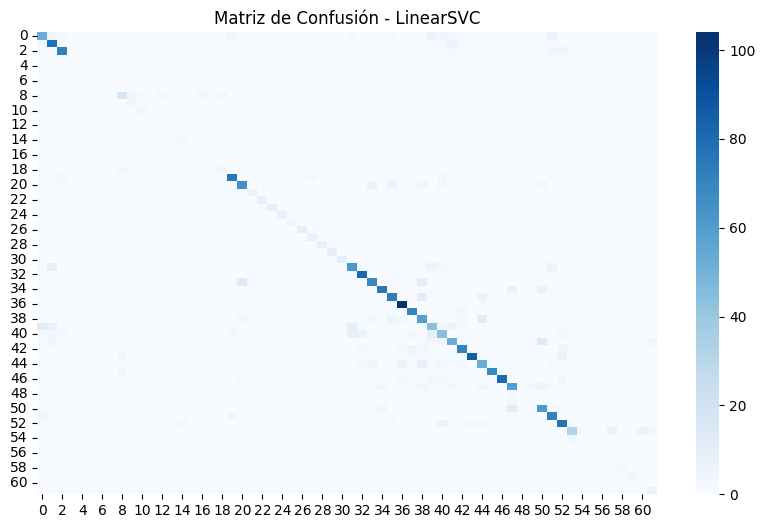

In [29]:

# =========================================
# 6. MATRIZ DE CONFUSIÓN
# =========================================

best_model = LinearSVC()
best_model.fit(X_ros, y_ros)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10,6))
sns.heatmap(cm, cmap='Blues')
plt.title("Matriz de Confusión - LinearSVC")
plt.show()


In [30]:
# DEEP LEARNING - MLP

# Convertir datos
X_train_dl = X_ros.toarray()
X_test_dl = X_test.toarray()

# Codificar etiquetas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_ros)
y_test_enc = le.transform(y_test)

# One-hot encoding
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

# Modelo MLP
model_dl = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dl.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

# Compilación
model_dl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
history = model_dl.fit(
    X_train_dl,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Evaluación
loss, acc = model_dl.evaluate(X_test_dl, y_test_cat)

print("\n=== MLP ===")
print("Accuracy:", acc)

Epoch 1/5


/Users/ximenacortes/Downloads/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6213 - loss: 1.6938 - val_accuracy: 0.1076 - val_loss: 5.2703
Epoch 2/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8282 - loss: 0.5981 - val_accuracy: 0.1983 - val_loss: 3.6058
Epoch 3/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8707 - loss: 0.4291 - val_accuracy: 0.1893 - val_loss: 2.7876
Epoch 4/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8961 - loss: 0.3370 - val_accuracy: 0.2971 - val_loss: 2.1762
Epoch 5/5
717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9142 - loss: 0.2712 - val_accuracy: 0.3680 - val_loss: 1.6903
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.6792 - loss: 1.1424

=== MLP ===
Accuracy: 0.6791651844978333


In [31]:

print("RESUMEN MODELOS")
print(df_results)

print("\nMLP Accuracy:", round(acc, 3))


RESUMEN MODELOS
                    Accuracy        F1    Recall
LinearSVC           0.661479  0.662098  0.661479
RandomForest        0.657588  0.651560  0.657588
LogisticRegression  0.651220  0.656732  0.651220

MLP Accuracy: 0.679


/Users/ximenacortes/Downloads/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


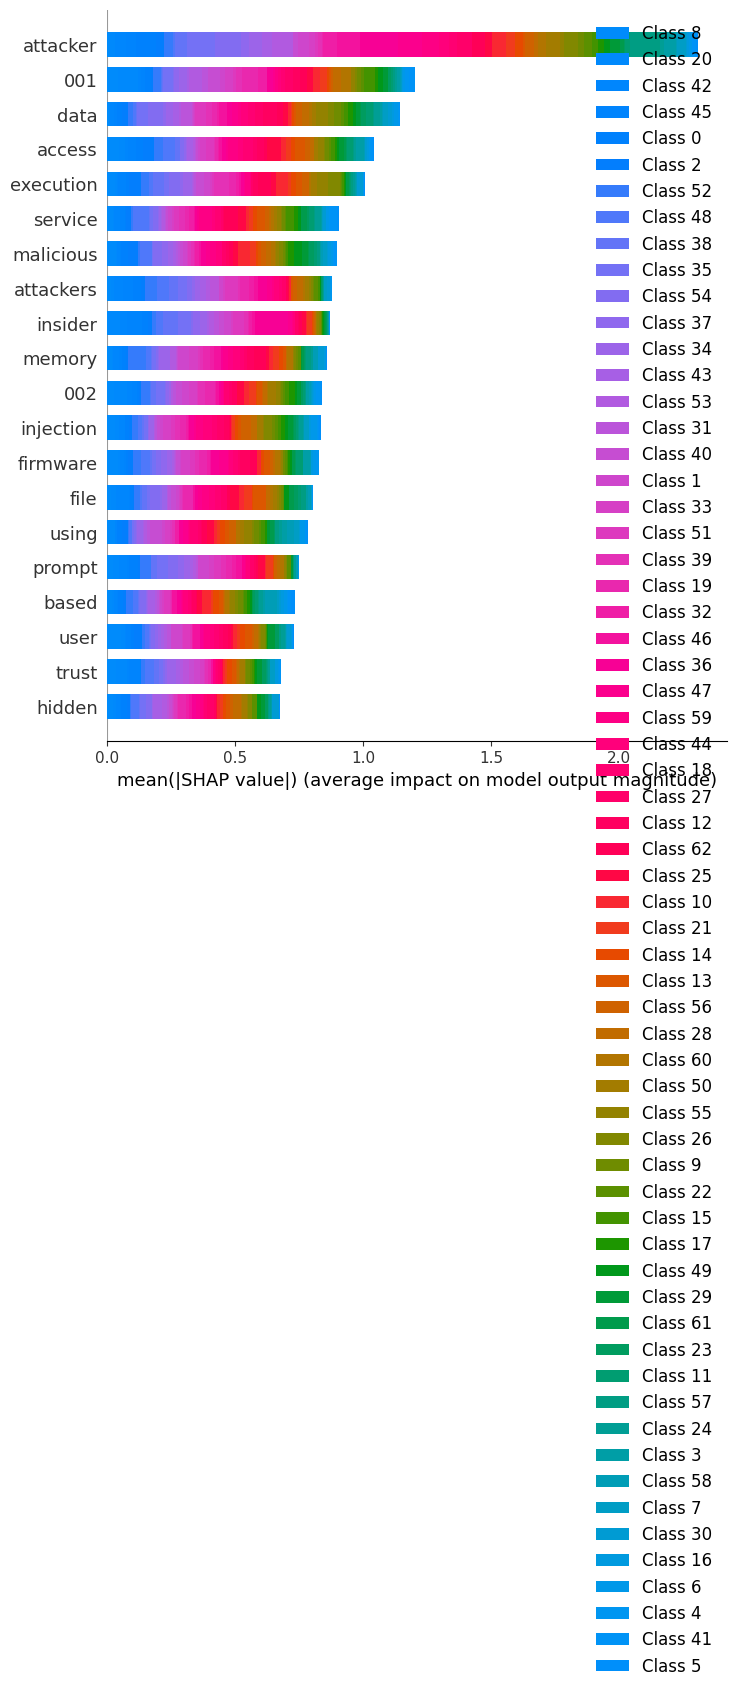

In [32]:

# Usamos el mejor modelo
best_model = LinearSVC()
best_model.fit(X_ros, y_ros)

# SHAP
explainer = shap.Explainer(best_model, X_train)

# tomar pocas muestras
shap_values = explainer(X_test[:100])

# gráfico
shap.summary_plot(
    shap_values,
    features=X_test[:100],
    feature_names=vectorizer.get_feature_names_out()
)


In [33]:

# 9. RESUMEN FINAL

print("\n=== RESUMEN FINAL ===")

for model, (acc, f1, recall) in results.items():
    print(f"{model}: Accuracy={acc:.3f}, F1={f1:.3f}, Recall={recall:.3f}")



=== RESUMEN FINAL ===
LinearSVC: Accuracy=0.661, F1=0.662, Recall=0.661
RandomForest: Accuracy=0.658, F1=0.652, Recall=0.658
LogisticRegression: Accuracy=0.651, F1=0.657, Recall=0.651


In [34]:

# después de entrenar modelos
best_model = LinearSVC()
best_model.fit(X_ros, y_ros)

# guardar modelo
joblib.dump(best_model, "model.pkl")

# guardar vectorizador
joblib.dump(vectorizer, "vectorizer.pkl")


['vectorizer.pkl']